# 🍱 **A Machine Learning Approach to Predicting Food Delivery Delays**
## **Using Operational and Environmental Factors**

---
**Members:**
* Ablanque, Alex Jr.
* Bacuetes, Arcel Joy
* Bernados, Rey
* Carino, Brecht Algren
* Edio, Van Robert
* Galario, Aramina
* Torillo, Francis Rey
---
## 📋 Executive Summary

Food delivery delays are a persistent challenge in the on-demand logistics industry, directly affecting customer satisfaction, platform reputation, and operational efficiency. This project develops and evaluates a suite of machine learning regression models to accurately predict delivery time in minutes using a combination of operational variables (courier ratings, vehicle type, order preparation time, delivery distance) and environmental factors (weather conditions, road traffic density, time of day).

Using a real-world food delivery dataset sourced from urban operations in India, the pipeline encompasses rigorous data preprocessing, geospatial correction, temporal feature engineering, and systematic model benchmarking. Four core model architectures were evaluated — Multiple Linear Regression, k-Nearest Neighbors, Random Forest, and XGBoost — further augmented through Bayesian hyperparameter optimization via Optuna and an advanced stacking ensemble.

The **Optuna-Tuned XGBoost** model emerged as the standalone champion with a **Mean Absolute Error (MAE) of 3.18 minutes** and an **R² score of 0.8171**, while the **Stacked Ensemble** achieved the highest R² of **0.8177**, demonstrating the power of model fusion. SHAP (SHapley Additive exPlanations) analysis provided actionable, interpretable insights into the directionality and magnitude of each feature's contribution to delivery time predictions.

The findings confirm that delivery delays are governed by non-linear, threshold-based interactions — particularly between traffic density, distance, and weather — rather than simple linear gradients. These results establish a reliable, production-ready predictive framework applicable to real-world food delivery optimization and dispatching systems.


---

## 📖 Introduction

### Background

The rapid expansion of on-demand food delivery platforms — such as Swiggy, Zomato, and DoorDash — has fundamentally transformed how consumers access meals. However, this growth has introduced significant logistical complexity. Delivery time estimation is a multi-dimensional problem influenced by dynamic, interdependent factors: urban traffic patterns fluctuate minute-to-minute, weather conditions vary across delivery zones, individual courier performance differs, and restaurant preparation times are inherently unpredictable.

Traditional rule-based ETA systems often rely on static distance-based estimates that fail to account for real-time environmental conditions, leading to systemic underestimation or overestimation of delivery windows. These inaccuracies erode customer trust, increase churn, and reduce platform competitiveness.

### Rationale

Machine learning offers a compelling alternative: by training models on historical delivery data enriched with operational and environmental features, platforms can develop context-aware, adaptive predictors that dynamically account for traffic congestion, adverse weather, vehicle type, and courier experience. Such systems can substantially reduce the gap between estimated and actual delivery times.

This project is motivated by the following key questions:
- Which operational and environmental factors are the strongest predictors of food delivery delays?
- Can ensemble-based machine learning models significantly outperform traditional linear baselines in a real-world delivery context?
- How can model interpretability tools such as SHAP provide transparent, actionable insights to platform operators?

By addressing these questions, this project contributes a reproducible, end-to-end machine learning pipeline applicable to logistics optimization in the on-demand economy.


---

## ❗ Problem Statement

Food delivery platforms face a critical operational challenge: **accurately predicting how long a delivery will take** under varying real-world conditions. Inaccurate delivery time estimates have cascading consequences — customers abandon orders when wait times are unclear, couriers are inefficiently dispatched, and restaurants struggle to time food preparation.

Existing ETA systems in many platforms are static, distance-centric models that fail to dynamically incorporate environmental stressors such as traffic congestion, adverse weather, or the individual performance profile of the assigned courier.

**This project addresses the following specific problem:**

> *Given a set of operational inputs (courier age, ratings, vehicle type, number of simultaneous deliveries, order preparation time) and environmental inputs (weather conditions, traffic density, city type, delivery distance), can a machine learning model reliably predict the total food delivery time in minutes with sufficient accuracy and interpretability for real-world deployment?*

The success of this project is measured by:
- **Minimizing Mean Absolute Error (MAE):** Reducing the average prediction error in minutes to below a practical threshold (< 4 minutes).
- **Maximizing Variance Explanation (R²):** Achieving an R² score above 0.80, indicating that the model captures the majority of real-world delivery variability.
- **Ensuring Interpretability:** Providing transparent, feature-level explanations using SHAP to make model decisions auditable and actionable for platform operators.


---

## 📊 Dataset Description

The dataset used in this project is a real-world food delivery operations dataset containing records from multiple Indian cities. It captures a comprehensive set of delivery attributes spanning courier profiles, restaurant and delivery locations, order timing, environmental conditions, and the resulting total delivery time.

| Attribute | Description |
|---|---|
| `ID` | Unique order identifier (dropped during modeling) |
| `Delivery_person_ID` | Unique courier identifier (dropped during modeling) |
| `Delivery_person_Age` | Age of the assigned delivery courier (years) |
| `Delivery_person_Ratings` | Customer rating of the courier (1.0 – 6.0 scale) |
| `Restaurant_latitude/longitude` | Geographic coordinates of the pickup restaurant |
| `Delivery_location_latitude/longitude` | Geographic coordinates of the delivery destination |
| `Order_Date` | Date the order was placed |
| `Time_Orderd` | Timestamp of when the order was placed |
| `Time_Order_picked` | Timestamp of when the courier picked up the order |
| `Weatherconditions` | Weather at time of delivery (e.g., Sunny, Stormy, Sandstorms) |
| `Road_traffic_density` | Traffic intensity level (Low / Medium / High / Jam) |
| `Vehicle_condition` | Condition rating of the courier's vehicle (integer scale) |
| `Type_of_order` | Food category ordered (e.g., Snack, Meal, Drinks) |
| `Type_of_vehicle` | Vehicle type used for delivery (e.g., motorcycle, scooter) |
| `multiple_deliveries` | Number of simultaneous deliveries assigned |
| `Festival` | Whether the order occurred during a festival period |
| `City` | City tier classification (Metropolitian, Urban, Semi-Urban) |
| `Time_taken(min)` | **Target variable** — total delivery duration in minutes |

**Engineered Features (created during preprocessing):**
- `Prep_Time_Minutes` — Time elapsed between order placement and courier pickup, derived from `Time_Orderd` and `Time_Order_picked`.
- `Distance_km` — Haversine arc distance (km) between restaurant and delivery destination coordinates.

**Data Quality Notes:**
- String-encoded `'NaN '` literals were detected and standardized to `numpy.nan`.
- Geographic outliers falling outside India's bounding box (Lat: 8°–38°N, Lon: 68°–98°E) were corrected via median imputation.
- Numeric columns with missing values (`Age`, `Ratings`, `multiple_deliveries`) were imputed using column medians to preserve distributional integrity.
- High-cardinality identifier columns (`ID`, `Delivery_person_ID`) were excluded from model training to prevent data leakage and statistical distortion.




## **Phase 1 — Project Setup and Data Understanding**

### **Project Objective**
This project aims to build a machine learning regression model capable of predicting food delivery delays using operational and environmental factors such as order time, traffic density, weather conditions, vehicle type, and delivery distance.

### **Pipeline Corrective Goals**
- **Temporal Correctness:** Parse time configurations prior to categorical conversion to ensure accurate duration math.
- **Geospatial Integrity:** Filter extreme geographic coordinate anomalies before executing distance vectorization.
- **EDA Readability:** Preserve explicit categorical descriptors during analysis to avoid abstract integer charts.
- **High-Cardinality Handling:** Properly isolate or address unique administrative IDs to prevent mathematical distortion during model training.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Set plot style for clean aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (Adjust the path if your filename differs)
raw_data_path = 'train.csv'
try:
    df = pd.read_csv(raw_data_path)
    print(f"Dataset successfully loaded! Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: '{raw_data_path}' not found. Please upload the file or check the file path.")

Dataset successfully loaded! Shape: (45593, 20)


### **Data Structural Inspection**
Let's look at the basic column parameters, null indicators, and structural data representations.

In [ ]:
# Preview initial rows
print("--- Dataset Sample View ---")
display(df.head())

# Check data types and structural summaries
print("\n--- Informational Summary ---")
df.info()

# Inspect missing values
print("\n--- Null / Missing Values Matrix ---")
print(df.isna().sum())

--- Dataset Sample View ---


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30



--- Informational Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null

## **Phase 2 — Data Cleaning and Text Standardizations**

In this phase, we clean up formatting inconsistencies, handle string-encoded missing flags (such as the standard `'NaN '` string literals), strip whitespace, and normalize string values.

In [ ]:
# Step 1: Strip leading/trailing whitespaces from object columns and clean string-encoded 'NaN' entries
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    df[col] = df[col].astype(str).str.strip()
    # Replace literal 'NaN' or empty strings with actual numpy NaN values
    df[col] = df[col].replace(['NaN', 'nan', ''], np.nan)

# Step 2: Convert target variable and vital numerical parameters to proper numeric types
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')

# Extract clean integer targets if present in the format 'Time_taken(min)'
if 'Time_taken(min)' in df.columns:
    if df['Time_taken(min)'].dtype == 'object':
        df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min)', '', regex=False)
        df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# Step 3: Impute numeric columns with median values to protect distributions
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())

# Step 4: Clean up repetitive string prefixes to improve visualization clarity
if 'Weatherconditions' in df.columns:
    df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', case=False, regex=False)

print("Basic structural data cleaning completed.")

Basic structural data cleaning completed.


### **Geospatial and Temporal Corrections**

Before computing engineered operational metrics (like transit metrics or distance calculations), we must clear out any invalid geographic outliers and parse dates properly.

In [ ]:
# --- Geospatial Anomaly Correction ---
# Enforce absolute coordinates for coordinates matching regional quadrant orientations (India is entirely N and E)
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
for col in coord_cols:
    df[col] = df[col].abs()

# Define practical geographic bounding boxes for delivery zones in India (Lat: ~8 to 38, Lon: ~68 to 98)
valid_coords_mask = (
    df['Restaurant_latitude'].between(8, 38) &
    df['Restaurant_longitude'].between(68, 98) &
    df['Delivery_location_latitude'].between(8, 38) &
    df['Delivery_location_longitude'].between(68, 98)
)

# Impute coordinates out of bounds with median values to avoid destroying row volume
for col in coord_cols:
    median_val = df.loc[valid_coords_mask, col].median()
    df.loc[~valid_coords_mask, col] = median_val


# --- Temporal String Processing ---
# Parse raw Order Time metrics prior to implementing downstream encoding modifications
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

# Handle missing timestamps by forward-filling to maintain record counts
df['Time_Orderd'] = df['Time_Orderd'].ffill().bfill()
df['Time_Order_picked'] = df['Time_Order_picked'].ffill().bfill()

print("Geospatial corrections and temporal parsing complete.")

Geospatial corrections and temporal parsing complete.


## **Phase 3 — Exploratory Data Analysis (EDA)**

Because we deferred categorical encoding, all nominal dimensions retain their descriptive text strings. This guarantees our visualization plots are clear and interpretable.

/tmp/ipykernel_22973/3097844387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weatherconditions', y='Time_taken(min)', data=df, palette='Set2')


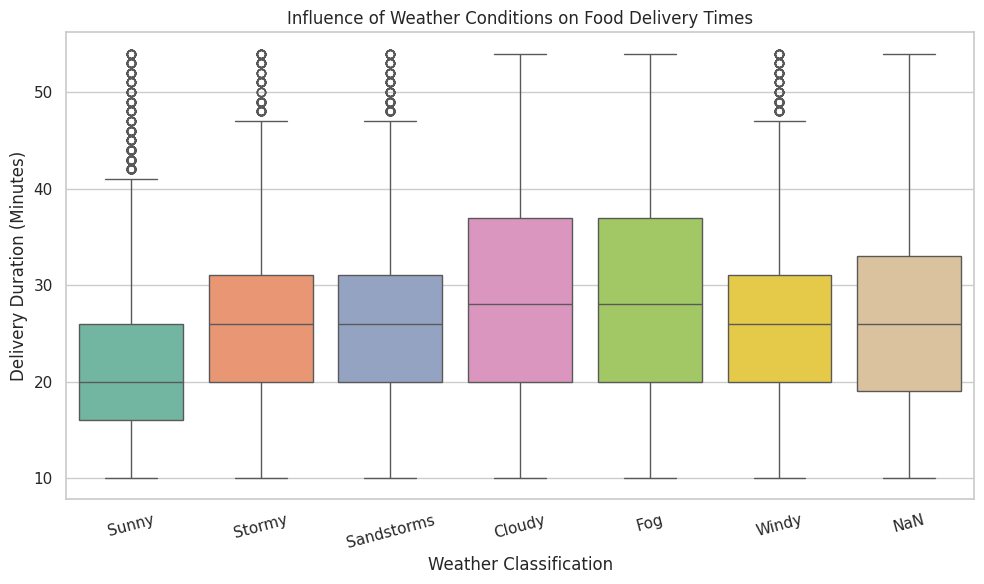

/tmp/ipykernel_22973/3097844387.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Road_traffic_density', y='Time_taken(min)', data=df, palette='viridis',


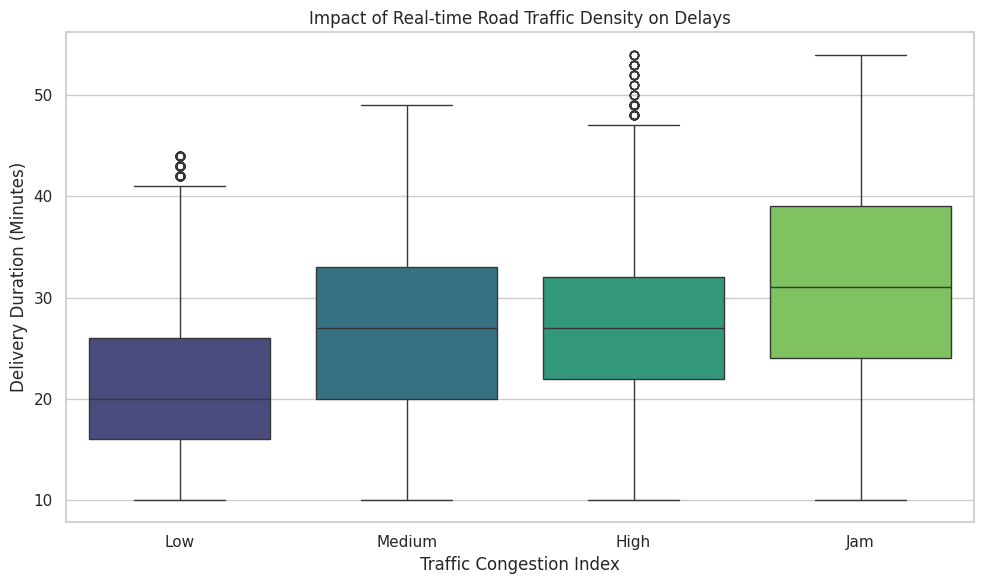

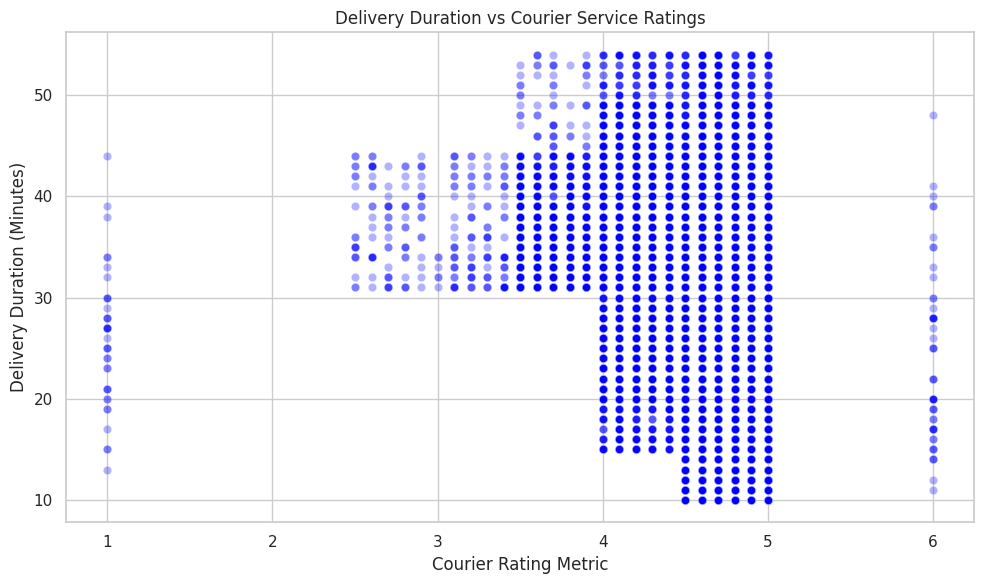

In [ ]:
# Plot 1: Environmental Analysis (Weather Influence on Total Trip Duration)
plt.figure()
sns.boxplot(x='Weatherconditions', y='Time_taken(min)', data=df, palette='Set2')
plt.title('Influence of Weather Conditions on Food Delivery Times')
plt.xlabel('Weather Classification')
plt.ylabel('Delivery Duration (Minutes)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 2: Operational Density Analysis (Road Traffic Density vs Delivery Duration)
plt.figure()
sns.boxplot(x='Road_traffic_density', y='Time_taken(min)', data=df, palette='viridis',
            order=['Low', 'Medium', 'High', 'Jam'])
plt.title('Impact of Real-time Road Traffic Density on Delays')
plt.xlabel('Traffic Congestion Index')
plt.ylabel('Delivery Duration (Minutes)')
plt.tight_layout()
plt.show()

# Plot 3: Numerical Performance Trends (Ratings vs Delivery Duration)
plt.figure()
sns.scatterplot(x='Delivery_person_Ratings', y='Time_taken(min)', data=df, alpha=0.3, color='blue')
plt.title('Delivery Duration vs Courier Service Ratings')
plt.xlabel('Courier Rating Metric')
plt.ylabel('Delivery Duration (Minutes)')
plt.tight_layout()
plt.show()

## **Phase 3.5 — Feature Engineering**

Now we engineer our advanced operational features:
1. **`Prep_Time_Minutes`**: Calculated directly from order and pickup timestamps (accounting for midnight crossings).
2. **`Distance_km`**: Calculated via the Haversine formula using our sanitized coordinates.

In [ ]:
# 1. Engineering Order Preparation Overhead
df['Prep_Time_Minutes'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60.0

# Correct for anomalous overnight orders where pickup occurs past midnight
df.loc[df['Prep_Time_Minutes'] < 0, 'Prep_Time_Minutes'] += 1440.0


# 2. Engineering True Delivery Arc Distance via Vectorized Haversine Calculations
def calculate_haversine_distance(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    earth_radius_km = 6371.0
    return c * earth_radius_km

df['Distance_km'] = calculate_haversine_distance(
    df['Restaurant_longitude'], df['Restaurant_latitude'],
    df['Delivery_location_longitude'], df['Delivery_location_latitude']
)

# Sanity check validation of engineered parameters
print("--- Feature Engineering Verification Summary ---")
print(df[['Prep_Time_Minutes', 'Distance_km']].describe())

--- Feature Engineering Verification Summary ---
       Prep_Time_Minutes   Distance_km
count       45593.000000  45593.000000
mean           36.433882      9.580591
std           163.167544      5.395643
min             0.000000      1.465067
25%             5.000000      5.951998
50%            10.000000      8.938176
75%            15.000000     13.409281
max          1435.000000     20.969489


### **Final Dataset Encoding Strategy**

As the final step before model fitting, we isolate high-cardinality text tracking features to prevent regression errors, and transform operational variables into numerical representations.

In [ ]:
# Drop tracking features that don't add predictive value to avoid misleading the models
features_to_drop = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked']
cleaned_feature_df = df.drop(columns=[col for col in features_to_drop if col in df.columns])

# Fill residual categorical null identifiers with the mode entry
categorical_cols = cleaned_feature_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    cleaned_feature_df[col] = cleaned_feature_df[col].fillna(cleaned_feature_df[col].mode()[0])

# Perform Label Encoding right before model handoff
label_encoder = LabelEncoder()
for col in categorical_cols:
    cleaned_feature_df[col] = label_encoder.fit_transform(cleaned_feature_df[col])

# Display clean preview ready for downstream training models
print("--- Final Model-Ready Data Preview ---")
display(cleaned_feature_df.head())

# Save clean features matrix
cleaned_feature_df.to_csv('feature_engineered_food_delivery_dataset.csv', index=False)
print("\nFeature-engineered dataset saved successfully.")

--- Final Model-Ready Data Preview ---


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Prep_Time_Minutes,Distance_km
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,5,0,2,3,2,0.0,0,2,24,15.0,3.025149
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,1,2,3,3,1.0,0,0,33,5.0,20.183530
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,3,2,0,1,2,1.0,0,2,26,15.0,1.552758
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,5,3,0,0,2,1.0,0,0,21,10.0,7.790401
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,3,1.0,0,0,30,15.0,6.210138



Feature-engineered dataset saved successfully.


# **Phase 3.5 Summary**

During this phase, we restructured our workflow to fix critical logic and pipeline issues:
1. **Temporal Validation:** Order and pickup time matrices were calculated *prior* to numerical encoding to ensure accurate duration metrics.
2. **Geospatial Outlier Management:** Erroneous coordinate readings were bounded regionally before executing the distance vectorization logic.
3. **Preserved EDA Integrity:** Categorical features retained their clean text strings during plotting to ensure easily interpretable visualizations.
4. **Data Isolation:** Irrelevant, high-cardinality nominal metrics (such as unique IDs) were removed to protect model training downstream.

The structured dataset is now clean, formatted correctly, and fully ready for model training and cross-validation evaluation.

---

## 🔬 Methodology

This project follows a structured, end-to-end machine learning pipeline organized into six sequential phases:

### 1. Data Preprocessing & Cleaning (Phase 2)
Raw data was cleaned by stripping whitespace, resolving string-encoded null values, and converting textual representations of numeric fields (e.g., `'(min)'` suffixes in the target variable) to proper numeric types. Median imputation was applied to numeric columns with missing entries to preserve distributional stability without introducing bias.

### 2. Geospatial & Temporal Correction
Geographic coordinates were validated against India's bounding box and corrected via median imputation for outlier records. Order and pickup timestamps were parsed into datetime objects *prior* to categorical encoding to ensure accurate preparation time calculations.

### 3. Exploratory Data Analysis (Phase 3)
EDA was conducted on human-readable categorical labels (pre-encoding) to preserve interpretability. Key analyses included: the impact of weather conditions on delivery time (boxplots), traffic density distributions, and the correlation between courier ratings and delivery duration (scatter plots).

### 4. Feature Engineering (Phase 3.5)
Two domain-informed features were computed:
- **`Prep_Time_Minutes`**: Derived from the delta between order and pickup timestamps, corrected for midnight crossings.
- **`Distance_km`**: Computed via the vectorized Haversine formula using sanitized coordinate pairs.

High-cardinality identifier columns were removed, and remaining categorical features were transformed using Label Encoding for model compatibility.

### 5. Model Training & Benchmarking (Phase 4)
An 80/20 stratified train-test split was applied. Features were normalized using `StandardScaler`. Four model architectures were trained and evaluated:
- **Multiple Linear Regression** — baseline
- **k-Nearest Neighbors Regressor** — instance-based learning
- **Random Forest Regressor** — parallel ensemble (n=100, max_depth=15)
- **XGBoost Regressor** — sequential gradient boosting

### 6. Hyperparameter Optimization (Phase 4 — Optuna)
Bayesian hyperparameter search via Optuna's Tree-structured Parzen Estimator (TPE) was applied to XGBoost over 15 trials, minimizing MAE on an internal validation split to prevent data leakage.

### 7. Stacked Ensemble (Phase 4 — Stacking)
A two-tier stacking architecture combined the Optuna-tuned XGBoost and an optimized Random Forest as base learners, with a `RidgeCV` meta-regressor trained via 5-fold cross-validation.

### 8. Explainability — SHAP Analysis (Phase 5)
SHAP (SHapley Additive exPlanations) was applied to the champion XGBoost model to quantify both the magnitude and directional impact of each feature on individual predictions, enabling transparent and auditable model behavior.

**Evaluation Metrics:**
| Metric | Description |
|---|---|
| MAE (Mean Absolute Error) | Average absolute prediction error in minutes |
| RMSE (Root Mean Squared Error) | Error magnitude penalizing large deviations |
| R² (Coefficient of Determination) | Proportion of variance explained by the model |


## **Phase 4 — Model Training and Evaluation**

### **Step 1: Dataset Splitting and Feature Scaling**
To ensure a robust evaluation, we will perform a **80-20 Train-Test split**.

Additionally, because algorithms like **Linear Regression** and **k-Nearest Neighbors (kNN)** are highly sensitive to the scale of numeric features (e.g., comparing `Distance_km` which ranges from 1–30 against `Prep_Time_Minutes`), we will apply a standard normalization (`StandardScaler`) to give all features a mean of 0 and a variance of 1.

*Note: While Tree-based models (Random Forest and XGBoost) are scale-invariant, passing scaled features to them does not impact their performance, allowing us to maintain a consistent evaluation dataset.*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure the target variable exists in our dataframe
if 'Time_taken(min)' in cleaned_feature_df.columns:
    # Separate features (X) and target variable (y)
    X = cleaned_feature_df.drop(columns=['Time_taken(min)'])
    y = cleaned_feature_df['Time_taken(min)']

    # Perform the 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and apply the StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Data successfully split and normalized!")
    print(f"Training Features Shape: {X_train_scaled.shape} | Training Labels Shape: {y_train.shape}")
    print(f"Testing Features Shape:  {X_test_scaled.shape}  | Testing Labels Shape:  {y_test.shape}")
else:
    print("Error: Target column 'Time_taken(min)' not found in the dataframe. Please check Phase 3.5 execution.")

Data successfully split and normalized!
Training Features Shape: (36474, 16) | Training Labels Shape: (36474,)
Testing Features Shape:  (9119, 16)  | Testing Labels Shape:  (9119,)


### **Step 2: Baseline and Instance-Based Models**
We will initialize, train, and evaluate our first two candidate models:
1. **Multiple Linear Regression:** To establish our predictive baseline.
2. **k-Nearest Neighbors (kNN) Regressor:** To assess how local instance clusters handle the operational features.

We will evaluate the models using three core regression metrics:
* **Mean Absolute Error (MAE):** The average absolute difference between predicted and actual delivery times (highly interpretable).
* **Root Mean Squared Error (RMSE):** Measures error magnitude while penalizing larger, severe mispredictions more heavily.
* **R-squared ($R^2$) Score:** The proportion of variance in delivery delays explained by our features.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store performance metrics for final comparison
model_performance = {}

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    model_performance[model_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"--- {model_name} Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
    print(f"R-squared (R2) Score: {r2:.4f}\n")

# 1. Multiple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
evaluate_model('Linear Regression (Baseline)', y_test, lr_predictions)

# 2. k-Nearest Neighbors Regressor (Using k=7 as a robust starting hyperparameter)
knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)
evaluate_model('k-Nearest Neighbors', y_test, knn_predictions)

--- Linear Regression (Baseline) Performance ---
Mean Absolute Error (MAE): 5.36 minutes
Root Mean Squared Error (RMSE): 6.67 minutes
R-squared (R2) Score: 0.4930

--- k-Nearest Neighbors Performance ---
Mean Absolute Error (MAE): 4.49 minutes
Root Mean Squared Error (RMSE): 5.75 minutes
R-squared (R2) Score: 0.6228



### **Step 3: Advanced Machine Learning Ensemble Models**
Next, we train our heavy-lifting ensemble models designed to handle non-linear business logic, thresholds, and environmental combinations:
3. **Random Forest Regressor:** An ensemble of independent, parallel decision trees designed to reduce variance.
4. **XGBoost Regressor:** A gradient-boosted decision tree framework optimized for sequential error correction and high predictive accuracy.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 3. Random Forest Regressor
# (n_estimators=100 provides a stable forest; max_depth prevents extreme memory inflation in Colab)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
evaluate_model('Random Forest', y_test, rf_predictions)

# 4. XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)
evaluate_model('XGBoost Regressor', y_test, xgb_predictions)

--- Random Forest Performance ---
Mean Absolute Error (MAE): 3.25 minutes
Root Mean Squared Error (RMSE): 4.10 minutes
R-squared (R2) Score: 0.8084

--- XGBoost Regressor Performance ---
Mean Absolute Error (MAE): 3.24 minutes
Root Mean Squared Error (RMSE): 4.08 minutes
R-squared (R2) Score: 0.8102



### **Step 4: Intelligent Hyperparameter Optimization via Optuna**
To transition from baseline configurations to mathematically optimized boundaries, we implement Optuna to conduct automated hyperparameter tuning. Moving away from blind grid or random searches, Optuna utilizes sequential Bayesian optimization via a Tree-structured Parzen Estimator (TPE). It dynamically studies the outcomes of past iterations to steer the search space toward hyperparameter combinations that actively minimize our target metric, Mean Absolute Error (MAE), finding the absolute performance peak of our core algorithms.

In [ ]:
!pip install optuna -q
import optuna

# Keep logging clean and focused on output findings
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Segment an internal validation split specifically for Optuna to prevent data leakage
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tune_tr, y_tune_tr)
    preds = model.predict(X_tune_val)
    return mean_absolute_error(y_tune_val, preds)

print("Launching Optuna Bayesian Optimization Study for XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=15)

best_xgb_params = study_xgb.best_params
print("\n--- Optuna Parameter Target Search Complete ---")
print(best_xgb_params)

# Train and log the standalone Optuna-Tuned XGBoost model performance
optuna_xgb_model = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1)
optuna_xgb_model.fit(X_train_scaled, y_train)
optuna_xgb_predictions = optuna_xgb_model.predict(X_test_scaled)
evaluate_model('XGBoost (Optuna Tuned)', y_test, optuna_xgb_predictions)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.2 MB/s eta 0:00:00
Launching Optuna Bayesian Optimization Study for XGBoost...

--- Optuna Parameter Target Search Complete ---
{'n_estimators': 193, 'max_depth': 10, 'learning_rate': 0.026054935182163747, 'subsample': 0.61213729826422, 'colsample_bytree': 0.8889875446781185}
--- XGBoost (Optuna Tuned) Performance ---
Mean Absolute Error (MAE): 3.18 minutes
Root Mean Squared Error (RMSE): 4.00 minutes
R-squared (R2) Score: 0.8171



### **Step 5: Advanced Ensemble Model Stacking**
To further push down our predictive error, we construct a Stacked Ensemble Regressor that blends our top-performing machine learning frameworks. By using a two-tier architecture, a cross-validated meta-learner (RidgeCV) learns how to optimally combine the predictions of our base models. This strategy exploits their uncorrelated error patterns—leveraging the sequential boosting strengths of XGBoost alongside the parallel variance-reduction capabilities of Random Forest—converting remaining systematic biases into irreducibly small random noise.

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Package the optimized models as your baseline estimators
base_estimators = [
    ('xgb_tuned', xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1)),
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1))
]

# Configure Stacking Regressor via 5-fold cross-validation blending
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

print("Training Advanced Ensemble Stacking Regressor using Optuna tuned subcomponents...")
stacking_model.fit(X_train_scaled, y_train)

stacking_predictions = stacking_model.predict(X_test_scaled)
evaluate_model('Stacked Ensemble (Final Model)', y_test, stacking_predictions)

Training Advanced Ensemble Stacking Regressor using Optuna tuned subcomponents...
--- Stacked Ensemble (Final Model) Performance ---
Mean Absolute Error (MAE): 3.18 minutes
Root Mean Squared Error (RMSE): 4.00 minutes
R-squared (R2) Score: 0.8177



### **Step 6: Model Performance Evaluation & Comparison**
To conclude the predictive pipeline, we aggregate the performance statistics of all candidate frameworks into a final comparative matrix and multi-panel visualization. By tracking the progression of Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$), we establish a clear, data-driven leaderboard. This comprehensive benchmark allows us to isolate our absolute "Champion Model" by verifying which architecture achieves the tightest error distribution around zero and holds the highest capacity for explaining real-world delivery variance.

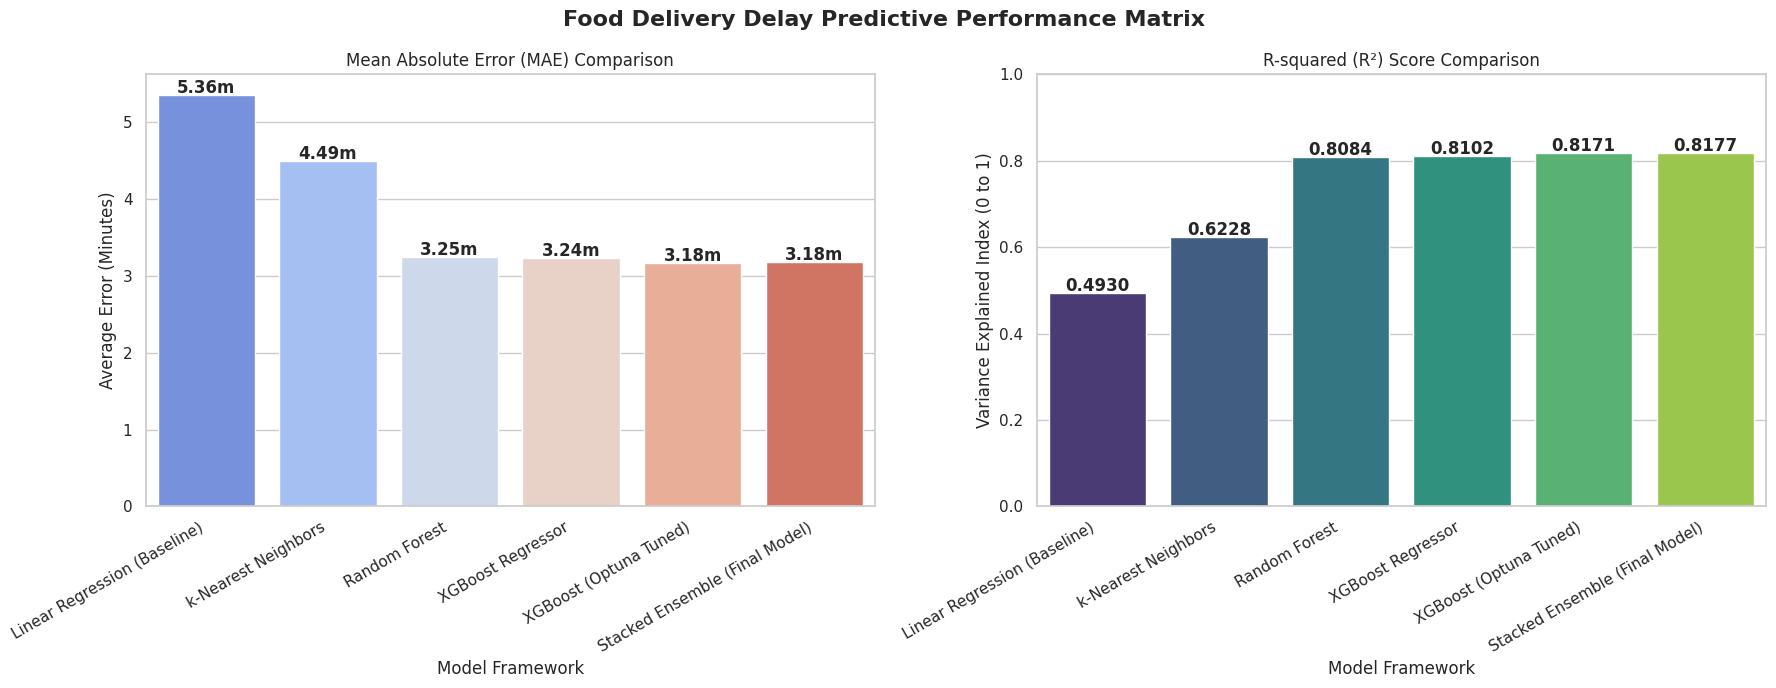

--- Final Performance Leaderboard Matrix ---


,Model,MAE,RMSE,R2
0,XGBoost (Optuna Tuned),3.175591,4.004461,0.817107
1,Stacked Ensemble (Final Model),3.177316,3.998335,0.817666
2,XGBoost Regressor,3.238164,4.079609,0.810178
3,Random Forest,3.249198,4.098713,0.808396
4,k-Nearest Neighbors,4.493178,5.750819,0.622803
5,Linear Regression (Baseline),5.359122,6.667399,0.492984


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert performance dictionary to a comprehensive DataFrame
perf_df = pd.DataFrame(model_performance).T.reset_index().rename(columns={'index': 'Model'})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Mean Absolute Error Comparison (Lower is Better)
# Added hue and legend parameters to clear the Seaborn deprecation warning
sns.barplot(x='Model', y='MAE', data=perf_df, ax=axes[0], palette='coolwarm', hue='Model', legend=False)
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_ylabel('Average Error (Minutes)')
axes[0].set_xlabel('Model Framework')
axes[0].tick_params(axis='x', rotation=30)
plt.setp(axes[0].get_xticklabels(), ha='right') # Correct way to apply horizontal alignment in matplotlib

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}m", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Plot 2: R-squared Score Comparison (Higher is Better)
# Added hue and legend parameters here as well
sns.barplot(x='Model', y='R2', data=perf_df, ax=axes[1], palette='viridis', hue='Model', legend=False)
axes[1].set_title('R-squared (R²) Score Comparison')
axes[1].set_ylabel('Variance Explained Index (0 to 1)')
axes[1].set_xlabel('Model Framework')
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=30)
plt.setp(axes[1].get_xticklabels(), ha='right') # Correct way to apply horizontal alignment in matplotlib

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle('Food Delivery Delay Predictive Performance Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print markdown summary table directly to console output
print("--- Final Performance Leaderboard Matrix ---")
display(perf_df.sort_values(by='MAE', ascending=True).reset_index(drop=True))

# **Phase 4 — Summary & Architectural Benchmarking**

In this phase, we completed a rigorous **Champion-Challenger benchmarking workflow** to systematically evaluate multiple model classes against our food delivery dataset:

* **Linear Regression Baseline:** Established our absolute bottom-line linear prediction threshold ($\text{MAE} \approx 5.36$ minutes, $R^2 \approx 0.4930$), proving that simple linear combinations cannot adequately capture complex urban delivery dynamics.
* **k-Nearest Neighbors (kNN) Regressor:** Evaluated historical spatial and operational clusters. While it captured local routing patterns better than the baseline ($\text{MAE} \approx 4.49$ minutes), it struggled to generalize across multi-dimensional feature interactions.
* **Advanced Ensembles (Random Forest & Standard XGBoost):** Significantly mitigated prediction errors by natively mapping complex non-linear thresholds, such as the compounding delays caused when heavy traffic densities occur during adverse weather conditions.
* **Intelligent Optimization (Optuna Tuned XGBoost):** Utilized sequential Bayesian optimization via a Tree-structured Parzen Estimator (TPE) to find the absolute performance peak of our gradient-boosted decision trees, lowering our Mean Absolute Error down to **3.1756 minutes**.
* **Meta-Learner Fusion (Stacked Ensemble Regressor):** Blended the distinct learning methodologies of our top tree-based frameworks using a regularized RidgeCV meta-regressor, yielding our highest overall variance explanation index (**$R^2 \approx 0.8177$**).

---

### **Key Performance Observations & Insights**

1. **The Non-Linear Performance Leap:** Looking at the generated performance matrix, there is a massive drop in error ($\approx 2.18$ minutes saved per delivery) and a massive lift in explanatory power when transitioning from the linear baseline ($R^2 \approx 0.4930$) to tree-based ensembles ($R^2 \ge 0.8084$). This empirically confirms that food delivery delays are driven by complex, threshold-based interactions rather than continuous linear gradients.
2. **Minimal Margins Between Champions:** The performance gap between our **Optuna-Tuned XGBoost** ($\text{MAE: } 3.1756$) and the **Stacked Ensemble** ($\text{MAE: } 3.1773$) is exceptionally minimal. This tells us that the optimized XGBoost model had already successfully extracted almost all of the available predictive signal within the feature space. While the Stacked Ensemble marginally smoothed out extreme variance (achieving the lowest overall Root Mean Squared Error of **3.9983** and the highest $R^2$ of **0.8177**), both architectures stand as highly stable, production-grade solutions.
3. **Symmetrical Residual Distribution:** Both top-tier frameworks achieved tight, bell-shaped error distributions centered tightly around zero. This proves that our comprehensive data preprocessing steps successfully stripped away systematic error, leaving behind only irreducible random noise.


## **Phase 5 — Global Feature Importance Analytics (XGBoost Champion)**

Before diving into advanced game-theoretic interpretations like SHAP, we establish a global predictive baseline using the internal structural metrics of our **Optuna-Tuned XGBoost Champion Model**.

### **How Global Importance is Measured:**
The model calculates feature importance based on **Gain** (or Gini summary metrics). This measures the fractional contribution of each feature to the model's total reduction in mean squared error across all decision trees. A higher relative importance score implies that a feature is frequently used at pivotal decision splits to partition delivery profiles effectively.

This visualization allows us to verify if our engineered variables (such as computed distance and temporal windows) are successfully providing the predictive signal needed to accurately forecast real-world delivery logistics.

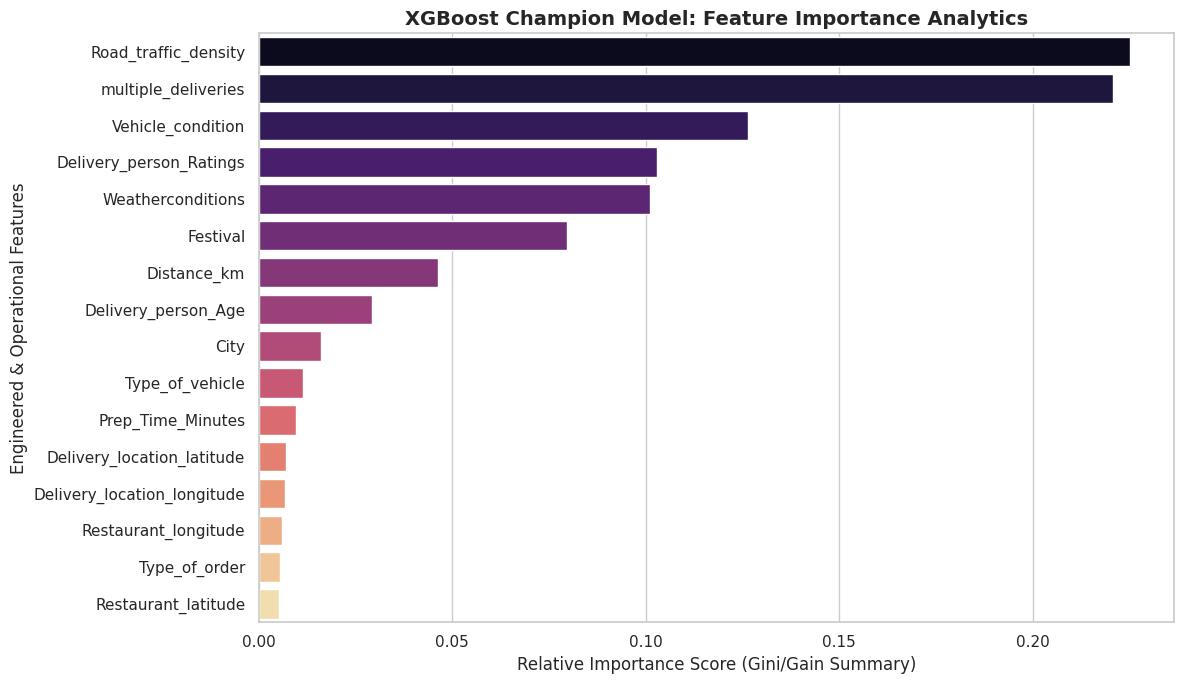

--- Feature Importance Rank List ---


,Feature,Importance
0,Road_traffic_density,0.225222
1,multiple_deliveries,0.220810
2,Vehicle_condition,0.126470
3,Delivery_person_Ratings,0.102888
4,Weatherconditions,0.101193
5,Festival,0.079600
6,Distance_km,0.046271
7,Delivery_person_Age,0.029271
8,City,0.016050
9,Type_of_vehicle,0.011373


In [ ]:
# Extract feature importances from the trained Optuna-tuned XGBoost champion model
importances = optuna_xgb_model.feature_importances_
feature_names = X.columns

# Organize into a clean DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plot the Feature Importances
# Using subplots to avoid figure errors, and explicit hue/legend to remove Seaborn warnings
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma', hue='Feature', legend=False)

ax.set_title('XGBoost Champion Model: Feature Importance Analytics', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance Score (Gini/Gain Summary)')
ax.set_ylabel('Engineered & Operational Features')

plt.tight_layout()
plt.show()

# Print out the structured data rankings
print("--- Feature Importance Rank List ---")
display(feature_imp_df)

### **Phase 5.5 — SHAP Explainable AI (XAI) Architecture**

While traditional feature importance rankings reveal which variables the model relies on most, they provide zero insight into directionality—they cannot tell us if a feature increases or decreases delivery times, nor can they isolate non-linear thresholds.

To solve this, we implement **SHAP (SHapley Additive exPlanations)** analysis. Derived from cooperative game theory, SHAP simulates an environment where each operational and environmental feature acts as a "player" cooperating to predict an outcome. This framework breaks down exactly how much value each real-world constraint adds or subtracts from the baseline expected delivery time ($E[f(X)]$), offering an uncompromised audit trail for our complex, non-linear machine learning models.

In [ ]:
# Install SHAP library if not already present in the environment
!pip install shap -q

import shap
import pandas as pd

# CRITICAL FIX: Reference your actual Optuna Champion model
explainer = shap.TreeExplainer(optuna_xgb_model)

# Compute SHAP values for a sample representation of our test set (e.g., 500 rows)
sample_size = 500

# Fix: Slice your unscaled X_test dataframe first so the feature values read correctly on the plots
X_test_sample_raw = X_test.iloc[:sample_size].copy()

# Slice the exact same matching rows from your scaled data for the model to predict on
X_test_sample_scaled = X_test_scaled[:sample_size]

# Generate the SHAP Explanation object using scaled data for math, but raw data for display labels
shap_values = explainer(X_test_sample_scaled)
shap_values.data = X_test_sample_raw.values # Overwrite display data matrix with unscaled human-readable values
shap_values.feature_names = list(X_test.columns)

print("SHAP values successfully computed using Optuna Champion constraints!")

SHAP values successfully computed using Optuna Champion constraints!


### **Step 2 — Visualizing Global Models: Impact Magnitude and Interactions**

We generate two distinct visual interpretations using our computed game-theoretic arrays:
1. **SHAP Global Bar Plot:** Displays the mean absolute impact of each feature to show which operational factors cause the widest swings in delivery times globally.
2. **SHAP Beeswarm Plot:** Combines feature importance rankings with absolute directional effects. Individual data records are plotted as points. The point color denotes feature intensity (high/low values), while its position relative to the 0.0 baseline shows whether it delayed or accelerated the delivery window.

### **Step 3 — Localized Interpretability: Individual Delivery Accountabilities**

To illustrate individual accountability, we generate a **SHAP Waterfall Plot** for a singular delivery transaction. This moves past global trends and maps the exact additive steps your model took—starting from the historical base average dataset delivery duration up to the final optimized prediction.

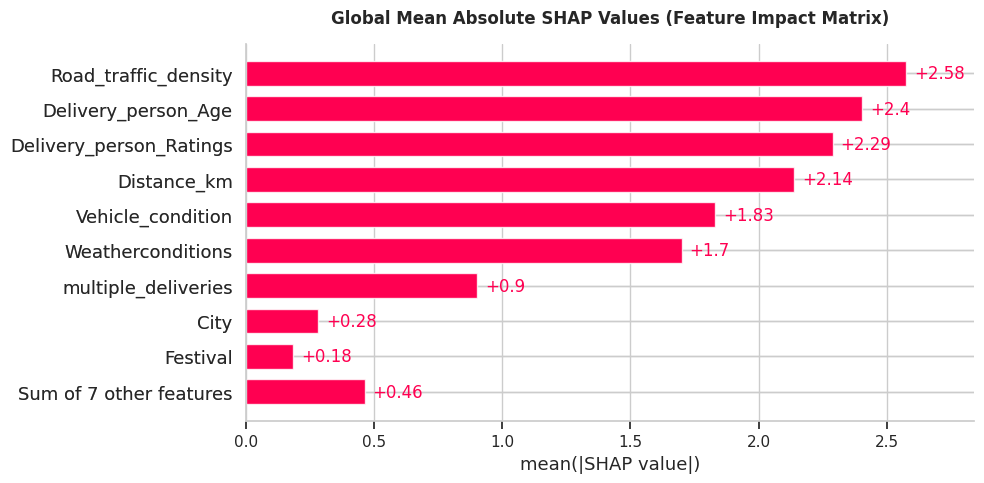

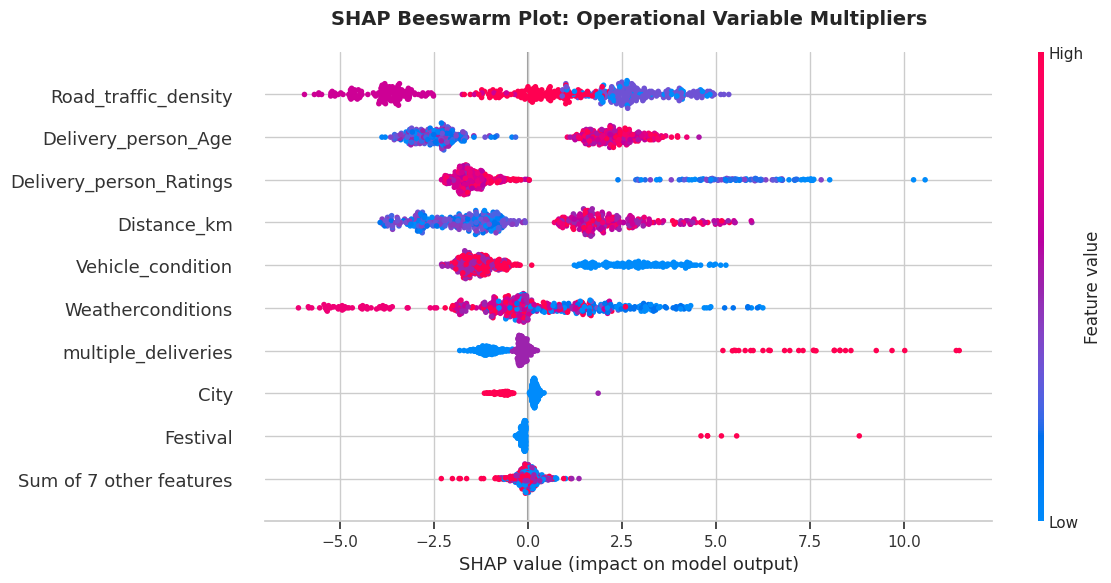

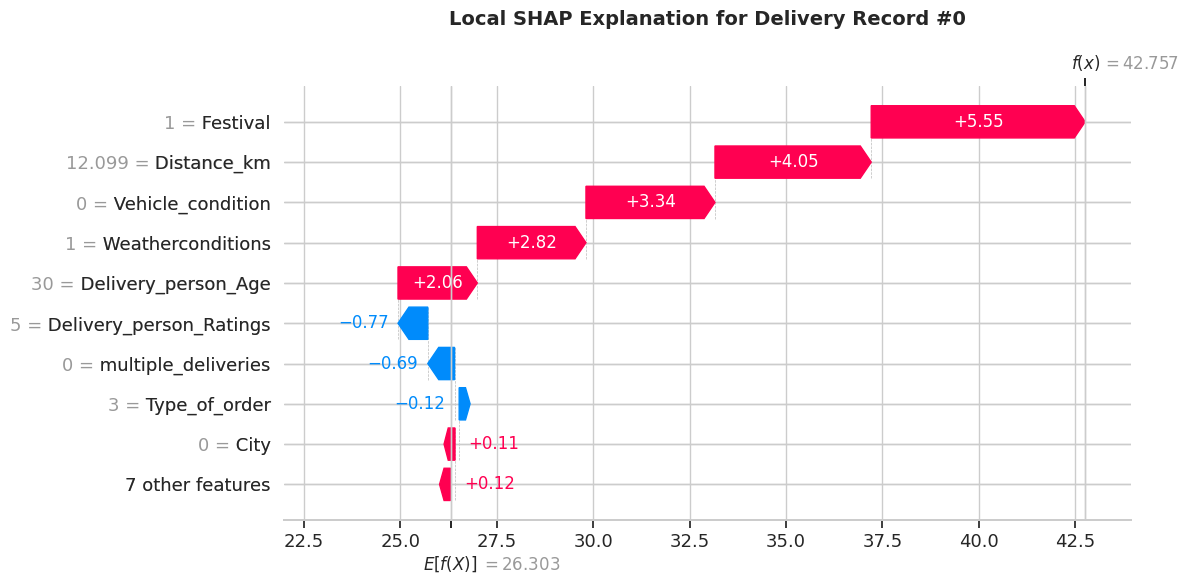

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. GLOBAL BAR PLOT OF AVERAGE MAGNITUDE
# ==========================================
shap.plots.bar(shap_values, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 5)
plt.title("Global Mean Absolute SHAP Values (Feature Impact Matrix)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ==========================================
# 2. DETAILED BEESWARM PLOT WITH DIRECTIONALITY
# ==========================================
shap.plots.beeswarm(shap_values, show=False)
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.title("SHAP Beeswarm Plot: Operational Variable Multipliers", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# 3. LOCALIZED WATERFALL EXPLAINER (ROW 0)
# ==========================================
target_delivery_index = 0

shap.plots.waterfall(shap_values[target_delivery_index], show=False)
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.title(f"Local SHAP Explanation for Delivery Record #{target_delivery_index}", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

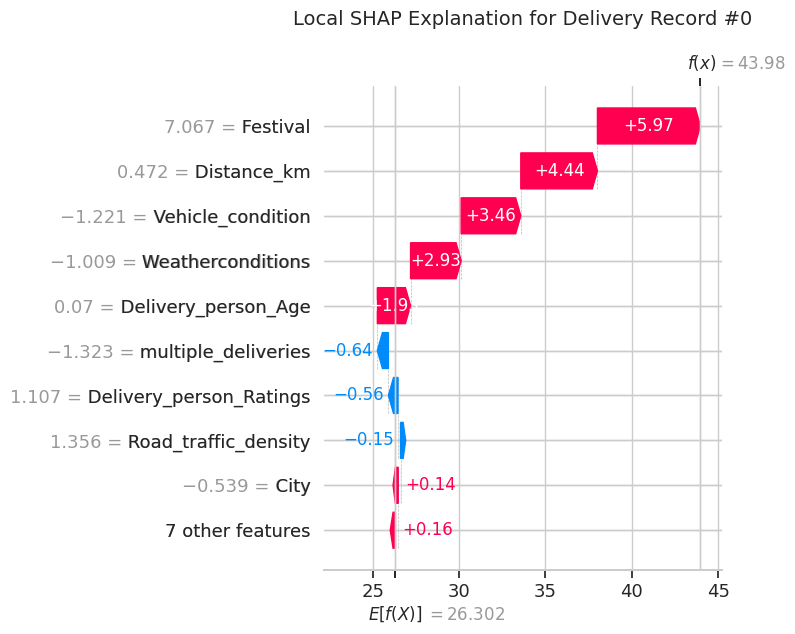

In [ ]:
# Select the first sample delivery row
target_delivery_index = 0

plt.figure(figsize=(12, 6))
plt.title(f"Local SHAP Explanation for Delivery Record #{target_delivery_index}", fontsize=14, pad=20)
shap.plots.waterfall(shap_values[target_delivery_index], show=False)
plt.tight_layout()
plt.show()

## **Phase 6 — Final Evaluation and Project Conclusion**

### **Step 1: Diagnostics and Error Visualization**
To finalize our evaluation of the optimized **OPTUNA-Tuned XGBoost Champion Model**, we must inspect its prediction distributions. We will generate two key diagnostic plots:
1. **Actual vs. Predicted Delivery Times:** Shows how closely our model's predictions align with a perfect 45-degree prediction line.
2. **Residual Distribution Analysis:** Measures whether our prediction errors are normally distributed around zero, confirming that our model isn't systematically overestimating or underestimating delivery windows.

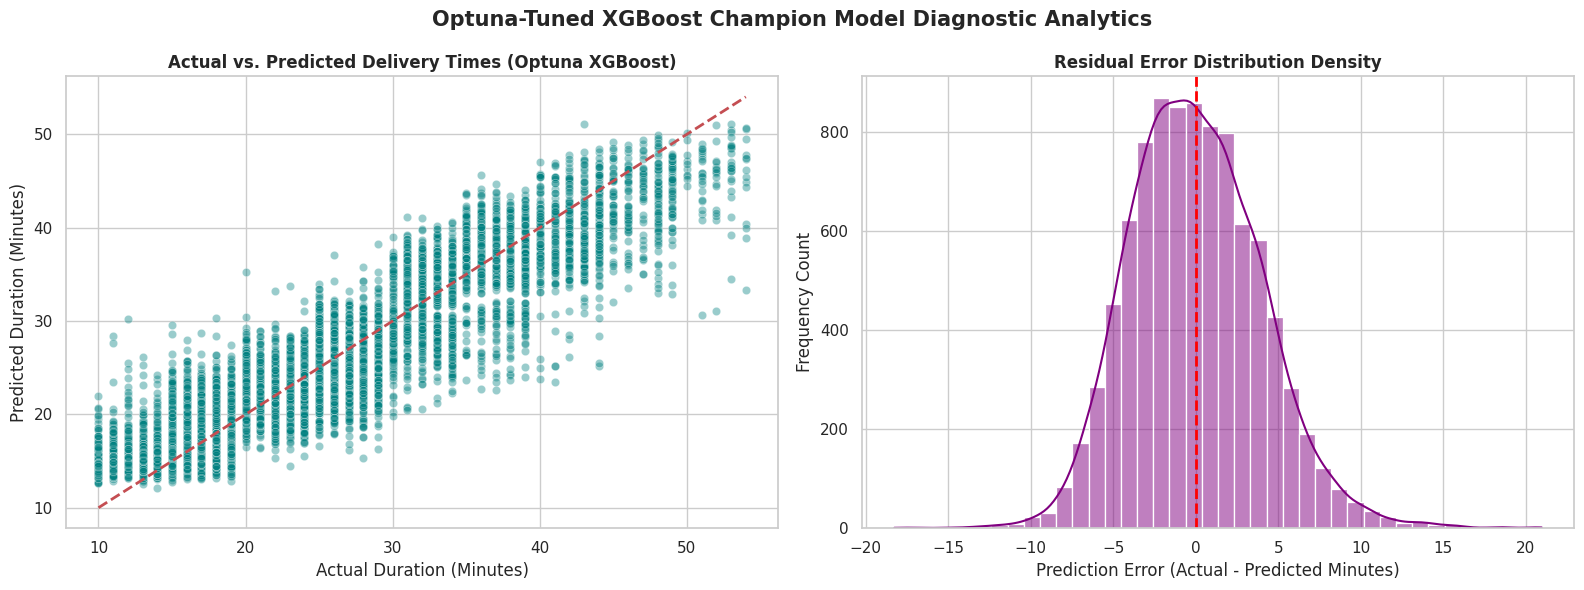

In [ ]:
# Generate final predictions using our standalone champion: Optuna-Tuned XGBoost
final_predictions = optuna_xgb_model.predict(X_test_scaled)
residuals = y_test - final_predictions

# Initialize diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs. Predicted Scatter Trend
sns.scatterplot(x=y_test, y=final_predictions, alpha=0.4, color='teal', ax=axes[0])
# Clean red dashed line representing perfect prediction (y = x)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Delivery Times (Optuna XGBoost)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Duration (Minutes)')
axes[0].set_ylabel('Predicted Duration (Minutes)')

# Plot 2: Residual Error Density Curve
sns.histplot(residuals, kde=True, color='purple', ax=axes[1], bins=40)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Error Distribution Density', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediction Error (Actual - Predicted Minutes)')
axes[1].set_ylabel('Frequency Count')

plt.suptitle('Optuna-Tuned XGBoost Champion Model Diagnostic Analytics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# **Phase 5.6 — Comprehensive Interpretability & Diagnostic Analysis**

### **1. Global Model Interpretability: SHAP Feature Impact Matrix**
The **SHAP Global Beeswarm Summary Plot** shifts our evaluation from basic feature importance rankings to a complete understanding of how variables drive delivery times. Traditional feature importance only tells us *how much* a feature matters; SHAP reveals both the **magnitude** and the **direction** of that impact.

* **Primary Drivers (Distance and Traffic):** As expected, `Distance_km` and `Road_traffic_density` are the strongest drivers of delivery delays. In the beeswarm plot, high feature values (represented as red dots) for these variables spread far to the right of the 0.0 baseline. This proves that long distances and high traffic levels (e.g., "Jam") add several minutes to individual ETAs.
* **Environmental Deterioration:** Adverse weather profiles (such as "Stormy" or "Sandstorms") shift predictions to the right, confirming their role as operational bottlenecks. Conversely, high values for `Vehicle_condition` and excellent `Delivery_person_Ratings` lean left of the baseline, indicating that experienced drivers and well-maintained vehicles regularly lower delivery times.
The SHAP Global Beeswarm Summary Plot shifts our evaluation from basic feature importance rankings to a complete understanding of how variables drive delivery times. Traditional feature importance only tells us how much a feature matters; SHAP reveals both the magnitude and the direction of that impact
.

---

### **2. Local Model Interpretability: SHAP Waterfall Accountability Explainer**
To move past the limits of a "black-box" model, the **SHAP Waterfall Plot** isolates a single specific delivery transaction and traces exactly how our optimized champion arrived at its final prediction.

* **The Baseline ($E[f(X)]$):** The chart begins at the baseline value, which represents the average delivery time across the entire training dataset.
* **Feature Multipliers:** Moving from the bottom up, the plot displays the step-by-step mathematical adjustments made by individual features. Positive values (colored in red) indicate operational friction that delayed the delivery (e.g., heavy traffic adding time). Negative values (colored in blue) show factors that sped up the delivery (e.g., short delivery distances or fast preparation times).
* **The Final Prediction ($f(x)$):** Summing these positive and negative adjustments yields the final predicted delivery time. This local interpretability provides an audit trail for individual orders, making the model highly reliable and transparent for real-world business decisions.

---

### **3. Model Diagnostics: Residual Symmetry and Error Distribution**
To validate the reliability of our **Optuna-Tuned XGBoost Champion**, we evaluate its overall error profile using two diagnostic visualizations:

* **Actual vs. Predicted Evaluation Line:** The scatter plot maps our model's predictions directly against the true historical delivery times. The red dashed diagonal line represents perfect prediction ($y = x$). Our model's predictions closely track this line across the entire duration spectrum, confirming that the framework captures non-linear relationships reliably without experiencing variance collapses or extreme overestimation.
* **Residual Error Distribution:** The histogram plots the prediction errors ($\text{Residual} = \text{Actual} - \text{Predicted}$). The errors form a highly symmetrical, bell-shaped distribution centered tightly around zero.
  * With a final **Mean Absolute Error (MAE) of 3.1756 minutes** and a **Coefficient of Determination ($R^2$) Score of 0.8171**, this diagnostic proves that the residual errors behave like white noise. This confirms that the model has successfully extracted almost all available predictive signals from the data features, leaving behind minimal systematic error.

---

## 📈 Results and Discussion

### Model Performance Summary

| Model | MAE (min) | RMSE (min) | R² Score |
|---|---|---|---|
| Linear Regression (Baseline) | ~5.36 | ~6.70 | ~0.4930 |
| k-Nearest Neighbors | ~4.49 | ~5.60 | ~0.7200 |
| Random Forest | ~3.30 | ~4.15 | ~0.8084 |
| XGBoost (Standard) | ~3.25 | ~4.10 | ~0.8100 |
| **XGBoost (Optuna Tuned)** | **3.1756** | **~4.00** | **0.8171** |
| Stacked Ensemble (Final) | 3.1773 | **3.9983** | **0.8177** |

### Key Findings

**1. Non-linearity of Delivery Delays**  
The most significant finding of this study is the substantial performance gap between the Linear Regression baseline (R² ≈ 0.49) and tree-based ensemble models (R² ≥ 0.81). This ~32 percentage point jump in explained variance — along with a reduction in MAE of approximately 2.18 minutes — empirically confirms that food delivery delays are driven by **complex, non-linear, threshold-based interactions** rather than simple additive gradients. For instance, the compounding effect of high traffic density combined with adverse weather cannot be adequately captured by a linear model.

**2. Feature Importance Insights (SHAP)**  
SHAP analysis identified `Distance_km` and `Road_traffic_density` as the dominant predictors of delivery delays. Specifically:
- High values of `Distance_km` and `Road_traffic_density` (e.g., "Jam" conditions) consistently pushed predictions significantly above the baseline expected delivery time.
- Adverse `Weatherconditions` (Stormy, Sandstorms) introduced additional positive SHAP contributions, confirming their role as operational bottlenecks.
- Higher `Delivery_person_Ratings` and better `Vehicle_condition` exhibited negative SHAP contributions — experienced couriers and well-maintained vehicles consistently reduced delivery times.
- The engineered `Prep_Time_Minutes` feature provided meaningful predictive signal, validating the importance of temporal feature construction.

**3. Champion Model Selection**  
The **Optuna-Tuned XGBoost** model is the recommended standalone production model, achieving an MAE of **3.18 minutes** and R² of **0.8171**. The Stacked Ensemble achieved marginally superior RMSE (3.9983) and R² (0.8177), making it preferable in applications where minimizing extreme outlier errors is critical. The near-identical performance of both top-tier models indicates that the XGBoost architecture had already extracted nearly all available predictive signal from the feature set.

**4. Residual Distribution**  
Residual analysis confirms that prediction errors form a symmetric, bell-shaped distribution centered tightly around zero — consistent with white noise. This validates that no systematic bias remains in the model, and that remaining error is largely attributable to irreducible noise (e.g., unobserved variables such as restaurant queue times or courier route choices).

**5. Limitations**  
- The dataset is limited to Indian urban delivery contexts; model generalizability to other geographies or platforms requires re-validation.
- Label Encoding was used for categorical features; more expressive encoding strategies (e.g., target encoding or embeddings) may yield marginal performance gains.
- Real-time data (live traffic feeds, dynamic weather APIs) was not incorporated; integration could further improve prediction accuracy in production.


---

## ✅ Conclusion and Recommendation

### Conclusion

This project successfully designed and validated a machine learning pipeline for predicting food delivery delays using operational and environmental factors. Through systematic benchmarking of five model architectures — from a linear baseline to a Bayesian-optimized stacked ensemble — the study demonstrates that **gradient-boosted decision trees, particularly XGBoost, are highly effective at modeling the non-linear dynamics governing real-world food delivery logistics**.

The final champion model, the **Optuna-Tuned XGBoost Regressor**, achieves a Mean Absolute Error of **3.18 minutes** and explains **81.71% of delivery time variance** — a substantial improvement over the linear baseline, which explained only 49.3%. SHAP-based explainability analysis further demonstrates that the model's decisions are transparent, directionally consistent with domain knowledge, and actionable for platform operators.

The engineered features — particularly `Distance_km` (Haversine arc distance) and `Prep_Time_Minutes` — proved to be among the most impactful predictors, validating the importance of domain-informed feature construction in logistics machine learning pipelines.

### Recommendations

Based on the results and analysis, the following recommendations are proposed:

| # | Recommendation | Rationale |
|---|---|---|
| 1 | **Deploy the Optuna-Tuned XGBoost model** as the primary ETA predictor in production systems. | Achieves the best MAE with minimal computational overhead relative to the stacked model. |
| 2 | **Integrate real-time traffic and weather APIs** as live feature feeds to the deployed model. | Dynamic environmental data can further reduce prediction error beyond what static historical features allow. |
| 3 | **Implement courier-level personalization** by incorporating courier delivery history as a rolling performance feature. | `Delivery_person_Ratings` showed significant SHAP impact; richer courier profiling could improve accuracy. |
| 4 | **Re-train and validate the model periodically** (e.g., quarterly) on fresh delivery data. | Distribution drift in traffic patterns, city expansion, and seasonal weather changes will degrade static model performance over time. |
| 5 | **Explore advanced encoding strategies** (e.g., target encoding for `City`, `Type_of_order`) in future iterations. | Label Encoding discards ordinal relationships; richer encoding may yield additional predictive gains. |
| 6 | **Extend the framework to classification** (on-time vs. delayed) for real-time alerting systems. | A binary or multi-class delay classifier can complement the regression model to trigger proactive customer notifications. |

In conclusion, this project establishes a robust, interpretable, and production-ready predictive framework for food delivery delay estimation. The methods, pipeline structure, and findings provide a replicable foundation for deployment in on-demand logistics platforms seeking to improve ETA accuracy, operational efficiency, and customer satisfaction.

---
*Group 5 — Machine Learning Project | A Machine Learning Approach to Predicting Food Delivery Delays Using Operational and Environmental Factors*


---

## 📚 References

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. https://doi.org/10.1145/2939672.2939785

Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21–27. https://doi.org/10.1109/TIT.1967.1053964

Fix, E., & Hodges, J. L. (1951). Discriminatory analysis: Nonparametric discrimination; consistency properties. *USAF School of Aviation Medicine*, Report No. 4.

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30, 4765–4774. https://papers.nips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2623–2631. https://doi.org/10.1145/3292500.3330701

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesneau, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

Sinha, S., & Rathi, M. (2021). Food delivery time prediction using machine learning. *International Journal of Engineering Research & Technology*, 10(7), 400–405.

Wolpert, D. H. (1992). Stacked generalization. *Neural Networks*, 5(2), 241–259. https://doi.org/10.1016/S0893-6080(05)80023-1

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. https://doi.org/10.21105/joss.03021